In [17]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
cols = ["letter"] + [f"f{i}" for i in range(1,17)]

df = pd.read_csv("letter-recognition.data", names=cols)

In [3]:
# df.head()
# df.tail()
# df.info()
# df.describe()

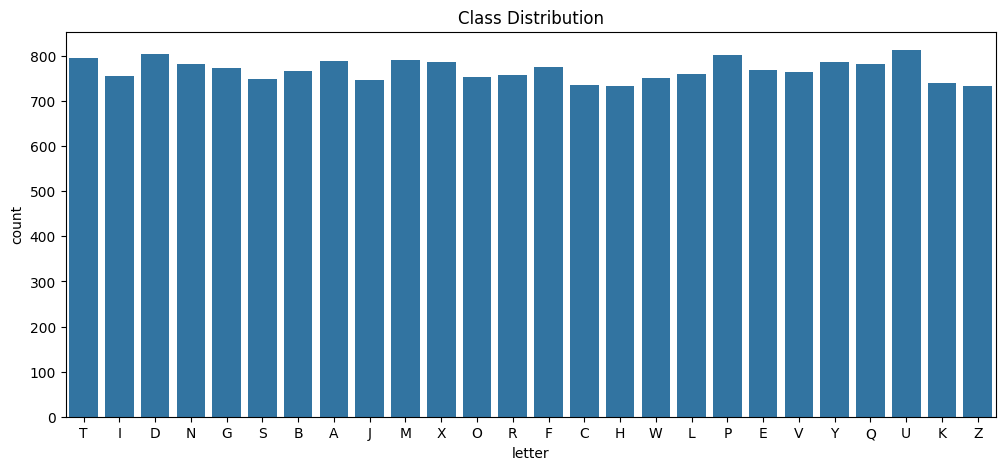

In [4]:
plt.figure(figsize=(12,5))
sns.countplot(x='letter', data=df)
plt.title("Class Distribution")
plt.show()

In [5]:
X = df.drop("letter", axis=1)
y = df["letter"]

In [6]:
le = LabelEncoder()
y = le.fit_transform(y)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [9]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(16,)),
    Dense(64, activation='relu'),
    Dense(26, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [12]:
model.fit(X_train, y_train, epochs=30, batch_size=32)

Epoch 1/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9486 - loss: 0.1607
Epoch 2/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9552 - loss: 0.1448
Epoch 3/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9576 - loss: 0.1347
Epoch 4/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9597 - loss: 0.1266
Epoch 5/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9648 - loss: 0.1142
Epoch 6/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9689 - loss: 0.1040
Epoch 7/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9693 - loss: 0.0983
Epoch 8/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9718 - loss: 0.0912
Epoch 9/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9738 - loss: 0.0870
Epoch 10/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9750 - loss: 0.0834
Epoch 11/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9771 - loss: 0.0749
Epoch 12/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [13]:
loss, acc = model.evaluate(X_test, y_test)

print("Accuracy:", acc)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9620 - loss: 0.1256
Accuracy: 0.9620000123977661


In [21]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred_classes))
print(classification_report(y_test, y_pred_classes))

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.962
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       149
           1       0.94      0.94      0.94       153
           2       0.98      0.92      0.95       137
           3       0.96      0.94      0.95       156
           4       0.94      0.96      0.95       141
           5       0.94      0.96      0.95       140
           6       0.93      0.96      0.94       160
           7       0.92      0.91      0.91       144
           8       1.00      0.92      0.96       146
           9       0.94      0.99      0.97       149
          10       0.92      0.92      0.92       130
          11       0.99      0.97      0.98       155
          12       0.99      0.97      0.98       168
          13       0.98      0.94      0.96       151
          14       0.97      0.96      0.96       145
          15       0.99      0.95      0.97       173
          16       0.97 